### STA 4724: Homework 3 - Due Friday, Oct. 18 
**Instructions**: Finsih the assign by directly answering the question or finishing the code in this Jupyter notebook. 

After you finish, submit the saved notebook to webcourses.

**Your name:**                     

**Your ID:**

## Question 1: kNN
For the *yeast* dataset, we want to predicte the compartment in a cell that a yeast protein will localize to based on properties of its sequence.

**(a)** Read the training and testing datasets.

In [ ]:
import pandas as pd
yeast_train = pd.read_csv('yeast_train.csv')
yeast_test = pd.read_csv('yeast_test.csv')
yeast_train

,id,f0,f1,f2,f3,f4,f5,f6,f7,class
0,1,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,2,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,3,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,4,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,5,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT
...,...,...,...,...,...,...,...,...,...,...
1034,1035,0.38,0.40,0.66,0.35,0.5,0.0,0.43,0.11,CYT
1035,1036,0.81,0.62,0.43,0.17,0.5,0.0,0.53,0.22,ME2
1036,1037,0.47,0.43,0.61,0.40,0.5,0.0,0.48,0.47,NUC
1037,1038,0.43,0.40,0.60,0.16,0.5,0.0,0.53,0.39,NUC


**(b)** Use leave-one-out cross validation to select the value of $k$ for kNN model.

Hint 1: try to apply kNN with a fixed $k$ first, then figure out how to use cross validation. In *yeast_3.txt*, I list the result when $k=3$ and you can use it as a reference.

Hint 2: Some of the $k$ values are not suitable to be the "best". You shouldn't even test them in the cross validation.

In [32]:
k = 3
from sklearn import neighbors 
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import cross_val_score, LeaveOneOut
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
# Separate features (X) and target (y) from training data
# Remove 'id' column and use only feature columns f0-f7
X_train = yeast_train.drop(['id', 'class'], axis=1)  # Features: f0, f1, f2, ..., f7
y_train = yeast_train['class']  # Target: class column

X_test = yeast_test.drop(['id', 'class'], axis=1)  # Features: f0, f1, f2, ..., f7
y_test= yeast_test['class']  # Target: class column

# Create and fit the kNN classifier
nbrs = neighbors.KNeighborsClassifier(k)
nbrs.fit(X_train, y_train)
predictions = nbrs.predict(X_test)
predictions

k_values = range(1, 21, 2)
cv_scores = []
loo = LeaveOneOut()
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross-validation on TRAINING data only
    scores = cross_val_score(knn, X_train, y_train, cv=loo)
    mean_score = scores.mean()
    cv_scores.append(mean_score)
best_k_cv = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)
best_k_cv

15

**(c)** Train the kNN model with the best $k$, and use it to predicte the testing data.

In [30]:
nbrs = neighbors.KNeighborsClassifier(n_neighbors=best_k_cv)
nbrs.fit(X_train, y_train)
predictions = nbrs.predict(X_test)
predictions
final_accuracy = accuracy_score(y_test, predictions)
final_accuracy

0.5842696629213483

**(d)** Print the confusion matrix, then manually compute the accuracy based on the confusion matrix. That is, don't call any built-in function for the accuracy, but type the equation you will use for calculating the accuracy.

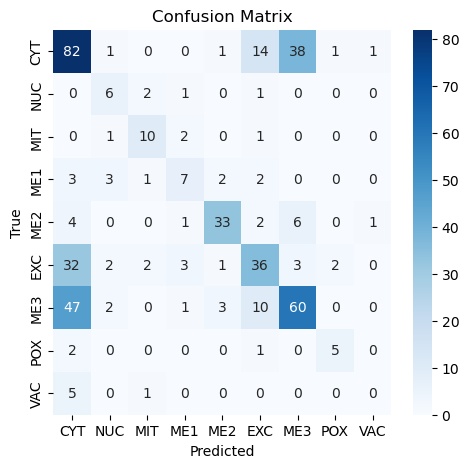

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=yeast_test['class'].unique(), yticklabels=yeast_test['class'].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()










## Question 2: Logistic Regression

We study the *myopia* dataset in this problem.

**(a)** Read the data file and make a scatterplot of MYOPIA vs. SPHEQ.

**(b)** Fit the logistic regression model of SPHEQ on MYOPIA

**(c)** Plot the logistic function found in (b) together with the scatterplot. You are looking for something like 

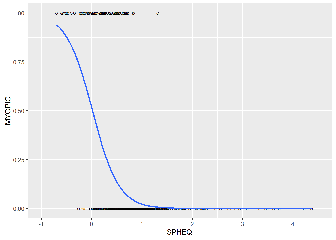

Hint: Although we didn't make this logistic function plot in class, the idea behind it is similar to the linear function plot in the earlier lecture. 

## Question 3: Naive Bayes
We have the *vote* datasets collected from 1984 United States Congressional Voting Records.

**(a)** Read the training and testing data file, and make any necessary preprocess so the data is ready to be used by naive bayes.

Hint: computer cannot read 'y/n' just like it cannot read tweets directly.

**(b)** Train the bayes model and use it to predict the voting result on the testing data.

**(c)** Plot the ROC curve and report AUC.

**(d, Extra question, No bonus point)** Based on the data in the traning set, what's the most significant character for the republican voters? Can you write a short program to find it out? 

Hint: We didn't cover this in class.

**Answer:** 